In [1]:
from prysm.interferogram import (
    abc_psd,
    render_synthetic_surface
)

from prysm.coordinates import make_xy_grid, cart_to_polar
from prysm.propagation import focus_fixed_sampling, unfocus_fixed_sampling
from prysm.geometry import circle
from prysm.x.dm import DM

from poi.influence_funcs import gaussian_influence_function

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.patches import Circle

# Making a Forward Model

## Configure a DM

In [2]:
# First we need a forward model of the system
# NOTE: Influence functions should peak at 1

# Basic inputs to a prysm DM
# - influence function
# - number of actuators in X and Y axes
# - separation of the actuators in the array containing the lattice, in units of samples

nact = 11
act_pitch = 6
samples_per_act = 42
sampling_pitch = act_pitch / samples_per_act

x, y = make_xy_grid(512, dx=sampling_pitch)
r, th = cart_to_polar(x, y)
influence_func = gaussian_influence_function(r, act_pitch)#np.sinc(x/act_pitch) * np.sinc(y/act_pitch)
# influence_func /= np.max(influence_func)
Nout = x.shape[0]
dm = DM(influence_func, Nout, nact, samples_per_act, rot=(0,0,0), shift=(samples_per_act, samples_per_act))

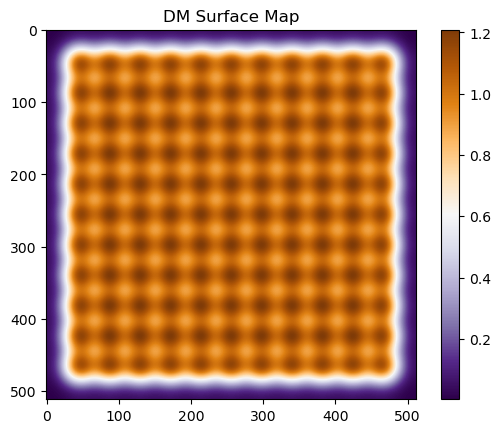

In [3]:
dm.actuators[:] = 1
sfe = dm.render(wfe=False)
plt.title("DM Surface Map")
plt.imshow(sfe, cmap="PuOr_r")
plt.colorbar()
dm.actuators[:] = 0

## Configure Wavefront Error

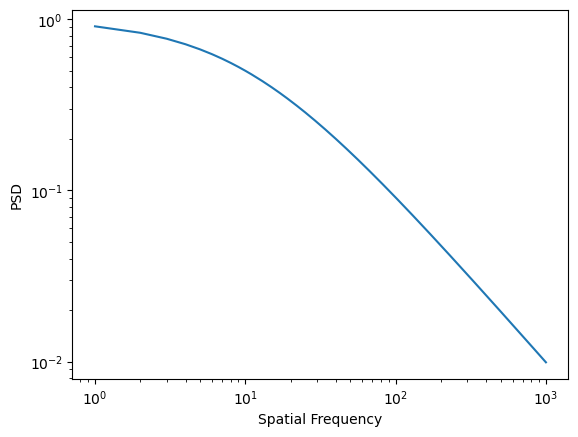

In [4]:
nu = np.arange(1,1000,1)
psd = abc_psd(nu, a=1, b=10, c=1)

plt.figure()
plt.plot(nu, psd)
plt.xscale('log')
plt.yscale('log')
plt.ylabel('PSD')
plt.xlabel('Spatial Frequency')
plt.show()

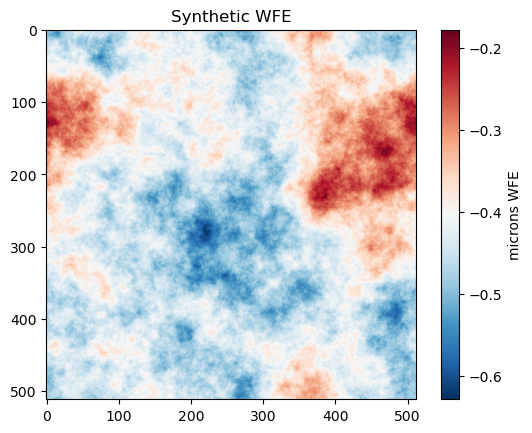

In [5]:
# Just picked ABC values until it looked about right
Npup = Nout
x, y, z = render_synthetic_surface(10, Npup, a=5e4, b=1/1000, c=3)

plt.figure()
plt.title('Synthetic WFE')
plt.imshow(z, cmap='RdBu_r')
plt.colorbar(label='microns WFE')
plt.show()

## Configure Diffraction Model

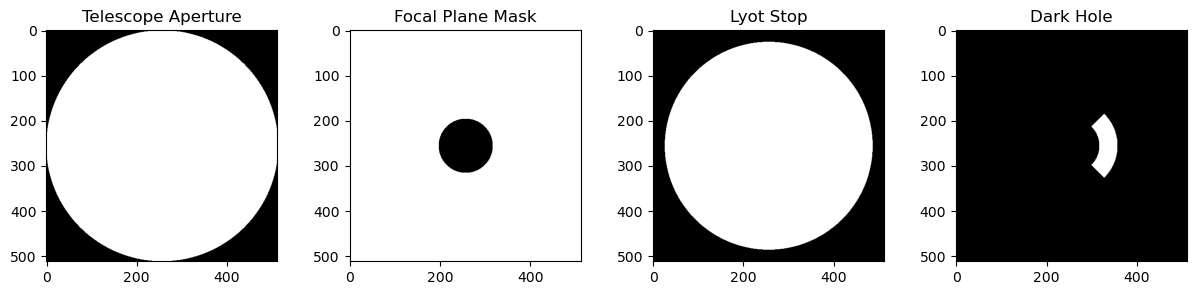

In [6]:
x, y = make_xy_grid(Npup, diameter=2)
r, t = cart_to_polar(x, y)
A = circle(1, r)
LS = circle(0.9, r)

# create pupil function and propagate
WVL = 1 # micron
EFL = 100 # mm
Dpup = 10 # mm
dx_img = 1/2 # microns
wvfnt = A * np.exp(1j * 2 * np.pi / WVL * z) # with error

# Sample field
focal = focus_fixed_sampling(wvfnt,
                             input_dx=Dpup / wvfnt.shape[0], # mm pupil
                             prop_dist=EFL, # mm focal length
                             wavelength=WVL, # microns
                             output_dx=dx_img, # microns
                             output_samples=wvfnt.shape[0])

# create a dark hole
um_to_LD = 1e-6 / (EFL * 1e-3) * (Dpup * 1e-3) / (WVL * 1e-6)
u, v = make_xy_grid(focal.shape, dx=dx_img * um_to_LD)
rho, psi = cart_to_polar(u, v)

dark_hole = np.zeros_like(u)
IWA = 3
OWA = 5
dark_hole[rho < OWA] = 1
dark_hole[rho < IWA] = 0
dark_hole[psi < -np.pi / 4] = 0
dark_hole[psi > np.pi / 4] = 0

FPM = np.ones_like(u)
FPM[ rho < IWA] = 0

focal_intensity = np.abs(focal)**2

plt.figure(figsize=[15,3])
plt.subplot(141)
plt.imshow(A, cmap='gray')
plt.title('Telescope Aperture')
plt.subplot(142)
plt.imshow(FPM, cmap='gray')
plt.title('Focal Plane Mask')
plt.subplot(143)
plt.imshow(LS, cmap='gray')
plt.title('Lyot Stop')
plt.subplot(144)
plt.imshow(dark_hole, cmap='gray')
plt.title('Dark Hole')
plt.show()

In [7]:
def snap_image(pupil_wfe=np.zeros_like(A), include_fpm=True):
    """take intensity image given a pupil wfe in microns

    Parameters
    ----------
    pupil_wfe : ndarray, optional
        wavefront error in microns, by default np.ones_like(A)
    """

    # create nominal wavefront
    wfe = np.exp(1j * 2 * np.pi / WVL * pupil_wfe)
    wvfnt_to_prop = wfe * wvfnt

    # propagate to focus
    focal = focus_fixed_sampling(wvfnt_to_prop,
                                input_dx=Dpup / wvfnt.shape[0], # mm pupil
                                prop_dist=EFL, # mm focal length
                                wavelength=WVL, # microns
                                output_dx=dx_img, # microns
                                output_samples=wvfnt.shape[0])
    
    if include_fpm:
        focal *= FPM

    lyot = unfocus_fixed_sampling(focal,
                                input_dx=dx_img, # um
                                prop_dist=EFL, # mm focal length
                                wavelength=WVL, # microns
                                output_dx=Dpup / wvfnt.shape[0], # mm
                                output_samples=wvfnt.shape[0])
    
    lyot *= LS

    coro = focus_fixed_sampling(lyot,
                                input_dx=Dpup / wvfnt.shape[0], # mm pupil
                                prop_dist=EFL, # mm focal length
                                wavelength=WVL, # microns
                                output_dx=dx_img, # microns
                                output_samples=wvfnt.shape[0])
    
    return np.abs(coro)**2


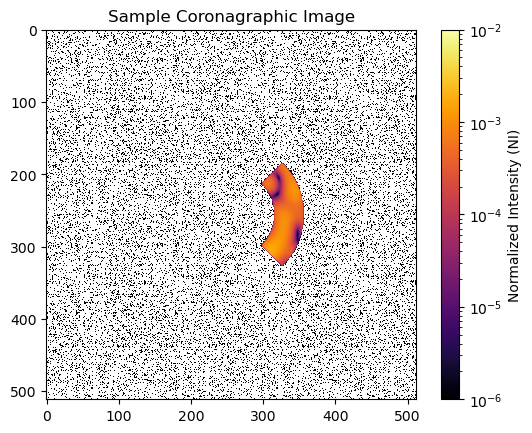

In [8]:
ref_contrast = snap_image(include_fpm=False).max()

plt.figure()
plt.title("Sample Coronagraphic Image")
plt.imshow(snap_image() / ref_contrast * dark_hole, cmap='inferno', norm=LogNorm(vmin=1e-6, vmax=1e-2))
plt.colorbar(label="Normalized Intensity (NI)")
plt.show()

# Speckle Nulling

In [9]:
from poi.speckle_nulling import SpeckleNulling

sn = SpeckleNulling(propagation=snap_image,
                    dx_img=dx_img,
                    epd=Dpup,
                    efl=EFL,
                    wvl=WVL,
                    dm=dm, 
                    dh=dark_hole,
                    ref_contrast=ref_contrast)

## Apply Waffle Pattern at maximum DM frequency

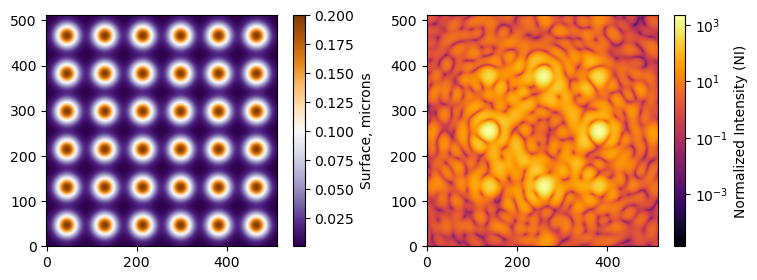

In [10]:
waffle_image, waffle_dm = sn.get_image_center()

plt.figure(figsize=[9,3])
plt.subplot(121)
plt.imshow(waffle_dm, cmap="PuOr_r", origin="lower")
plt.colorbar(label="Surface, microns")
plt.subplot(122)
plt.imshow(waffle_image, cmap="inferno", norm=LogNorm(), origin="lower")
plt.colorbar(label="Normalized Intensity (NI)")
plt.show()

## Step speckle nulling

In [11]:
import numpy as np

def azimuthal_average(image, center=None, angle_range=[-45, 45]):
    """
    Calculate the azimuthal average of an image over a specified angular range.
    Thanks to Claude AI by Anthropic for the function
    
    Parameters:
    -----------
    image : 2D numpy array
        The input image
    center : tuple, optional
        The (x,y) coordinates of the center. If None, uses the image center
    angle_range : tuple, optional
        The (min_angle, max_angle) in degrees for averaging. If None, uses full 360°
        
    Returns:
    --------
    radial_profile : numpy array
        The azimuthally averaged radial profile
    r_bins : numpy array
        The radial distances corresponding to the profile points
    """
    
    # Get image dimensions and center
    y, x = np.indices(image.shape)
    if center is None:
        center = ((x.max() - x.min()) / 2., (y.max() - y.min()) / 2.)
    
    # Calculate radius and angle for each pixel
    r = np.sqrt((x - center[0])**2 + (y - center[1])**2)
    theta = np.degrees(np.arctan2(y - center[1], x - center[0]))
    
    # Make theta range from 0 to 360
    theta = np.where(theta < 0, theta + 360, theta)
    
    # Set up angle range
    if angle_range is None:
        min_angle, max_angle = 0, 360
    else:
        min_angle, max_angle = angle_range
        # Ensure angles are in 0-360 range
        min_angle = min_angle % 360
        max_angle = max_angle % 360
    
    # Create mask for angular range
    if min_angle <= max_angle:
        mask = (theta >= min_angle) & (theta <= max_angle)
    else:  # Handle case where range crosses 0°
        mask = (theta >= min_angle) | (theta <= max_angle)
    
    # Apply mask to image and radius array
    masked_image = image[mask]
    masked_r = r[mask]
    
    # Define radius bins
    r_max = np.max(r)
    r_bins = np.linspace(0, r_max, min(int(r_max), 100))
    
    # Calculate radial profile
    radial_profile = np.zeros_like(r_bins)
    for i in range(len(r_bins)-1):
        r_mask = (masked_r >= r_bins[i]) & (masked_r < r_bins[i+1])
        if r_mask.any():
            radial_profile[i] = masked_image[r_mask].mean()
    
    return radial_profile, r_bins

In [12]:
MAX_ITERS = 25
images_sn = []
profiles = []
for _ in range(MAX_ITERS):
    img = sn.step()
    images_sn.append(img)
    pro, bins = azimuthal_average(img)
    profiles.append(pro)

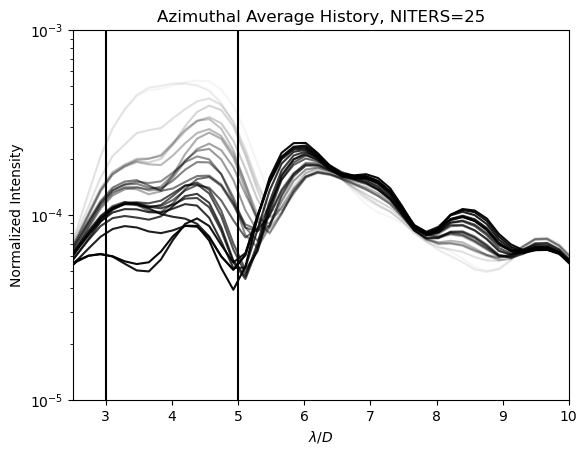

In [13]:
plt.figure()
plt.title(f"Azimuthal Average History, NITERS={MAX_ITERS}")
for i, pro in enumerate(profiles):
    plt.plot(bins * sn.image_dx_lamD, pro / ref_contrast, color="k", alpha=(1/MAX_ITERS)*(i))
plt.yscale("log")
plt.ylabel("Normalized Intensity")
plt.xlabel(r"$\lambda / D$")
plt.vlines(IWA, ymin=1e-7, ymax=1e-2, colors="k")
plt.vlines(OWA, ymin=1e-7, ymax=1e-2, colors="k")
plt.ylim([1e-5, 1e-3])
plt.xlim([2.5, 10])
plt.show()

# Implicit Electric Field Conjugation

In [14]:
# Set up a new DM
nact = 11
act_pitch = 6
samples_per_act = 42
sampling_pitch = act_pitch / samples_per_act

x, y = make_xy_grid(512, dx=sampling_pitch)
r, th = cart_to_polar(x, y)
influence_func = gaussian_influence_function(r, act_pitch)#np.sinc(x/act_pitch) * np.sinc(y/act_pitch)
# influence_func /= np.max(influence_func)
Nout = x.shape[0]
dm = DM(influence_func, Nout, nact, samples_per_act, rot=(0,0,0), shift=(samples_per_act, samples_per_act))

In [15]:
from poi.modes import poke_mode_sequence

xact, yact = make_xy_grid(nact, dx=act_pitch)
rhoact, thact = cart_to_polar(xact, yact)
circ_dm_mask = np.ones_like(xact)

modes = poke_mode_sequence(circ_dm_mask)

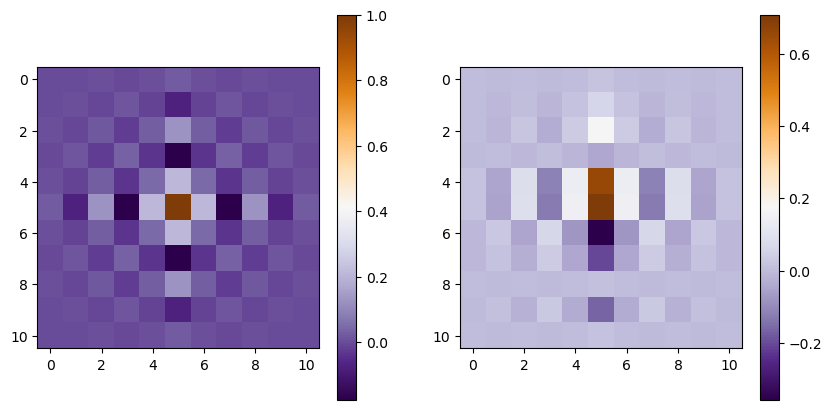

In [16]:
from poi.probes import create_sinc_probe, create_fourier_probes

amp = 1
probe_radius = 4.5 # is this L/D ?
shift = (0, 0)

dm_mask = np.ones([nact, nact])

probe1 = create_sinc_probe(Nacts=nact,
                          amp=amp,
                          probe_radius=probe_radius)

probe2 = create_sinc_probe(Nacts=nact,
                          amp=amp,
                          probe_radius=probe_radius,
                          offset=shift,
                          probe_phase=np.pi / 4)

# probe1, probe2 = create_fourier_probes(dm_mask, 256, dx_img * um_to_LD, iwa=IWA, owa=OWA)

# probe1 = np.zeros_like(probe1)
# probe1[5,5] = 1
# probe2 = np.zeros_like(probe2)
# probe2[5,7] = 1


plt.figure(figsize=[10, 5])
plt.subplot(121)
plt.imshow(probe1, cmap="PuOr_r")
plt.colorbar()
plt.subplot(122)
plt.imshow(probe2, cmap="PuOr_r")
plt.colorbar()
plt.show()

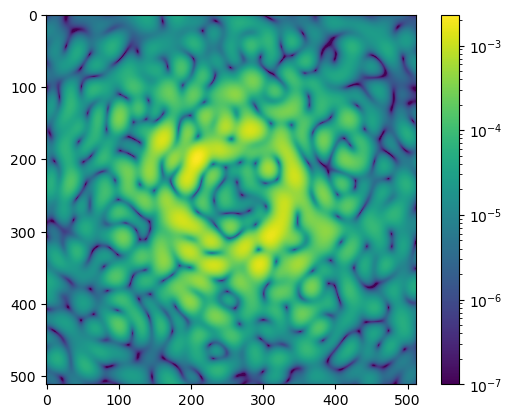

In [17]:
ref_contrast = snap_image(include_fpm=False)
ref_contrast = ref_contrast.max()

plt.imshow(snap_image() / ref_contrast, norm=LogNorm(vmin=1e-7))
plt.colorbar()

In [18]:
from poi.efc import iEFC

iefc = iEFC(snap_image, dm, modes, [probe1, probe2], dark_hole,
            probe_amplitude=20e-3, # radians, change to 20nm
            mode_amplitude=20e-3,
            ref_contrast=ref_contrast)

In [20]:
# try step forward
energy = []
mean_in_dh = []
images = []
betas = np.ones(4) * -2.5
amplitudes = np.array([10, 1, 1., 1., 1.]) * 1e-3
gains = [1, 0.1, 0.1, 0.1, 0.1]
recompute_jacobian = [0, 1, 2]
profiles = []
for i in range(1):
    if i in recompute_jacobian:
        iefc.calibrate()
        iefc.compute_control_matrix(beta=betas[i])
    img = iefc.step(loop_gain=gains[i])
    pro, bins = azimuthal_average(img)
    profiles.append(pro)

    # NOTE: Investigate whether this is actually changing
    iefc.probe_amplitude = amplitudes[i]
    iefc.mode_amplitude = amplitudes[i]

121it [02:35,  1.28s/it]


Taking starter image at position zero


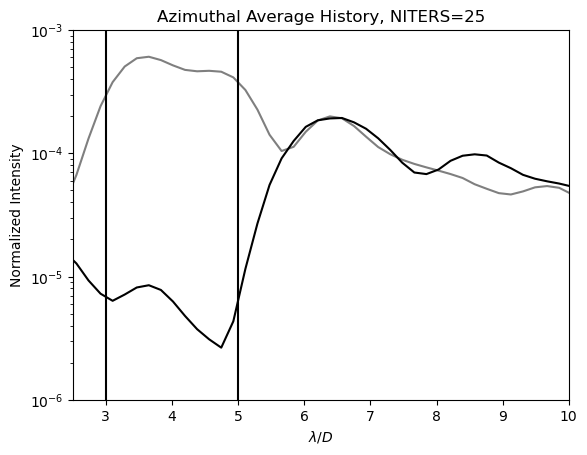

In [39]:
plt.figure()
plt.title(f"Azimuthal Average History, NITERS={MAX_ITERS}")
starter_pro, bins = azimuthal_average(iefc.images[0])
plt.plot(bins * sn.image_dx_lamD, starter_pro, color="k", alpha=1/2)
plt.plot(bins * sn.image_dx_lamD, pro, color="k", alpha=1)
plt.yscale("log")
plt.ylabel("Normalized Intensity")
plt.xlabel(r"$\lambda / D$")
plt.vlines(IWA, ymin=1e-7, ymax=1e-2, colors="k")
plt.vlines(OWA, ymin=1e-7, ymax=1e-2, colors="k")
plt.ylim([1e-6, 1e-3])
plt.xlim([2.5, 10])
plt.show()

In [26]:
profiles

[array([5.10428724e-05, 1.67869626e-05, 5.68246307e-06, 1.15267976e-05,
        1.98981558e-05, 2.26401379e-05, 2.00462453e-05, 1.57522456e-05,
        1.33680969e-05, 1.49518114e-05, 1.66182222e-05, 1.83730379e-05,
        1.82290339e-05, 1.59208883e-05, 1.27599056e-05, 9.29334503e-06,
        7.25321131e-06, 6.35246843e-06, 7.14128921e-06, 8.14814000e-06,
        8.49837298e-06, 7.77955452e-06, 6.26783332e-06, 4.78332928e-06,
        3.73718127e-06, 3.09137733e-06, 2.64624356e-06, 4.32945016e-06,
        1.15357646e-05, 2.69611379e-05, 5.53366959e-05, 9.09657359e-05,
        1.25963361e-04, 1.63961726e-04, 1.85359779e-04, 1.91938205e-04,
        1.93589676e-04, 1.78432855e-04, 1.58265947e-04, 1.32516318e-04,
        1.06627879e-04, 8.38863155e-05, 6.98606946e-05, 6.78251013e-05,
        7.38536755e-05, 8.69627887e-05, 9.55841078e-05, 9.81644033e-05,
        9.59429955e-05, 8.40591208e-05, 7.57157394e-05, 6.69030604e-05,
        6.21977867e-05, 5.92639278e-05, 5.68393038e-05, 5.386715

In [27]:
profiles / ref_contrast

array([[5.49785369e-10, 1.80813226e-10, 6.12060980e-11, 1.24155722e-10,
        2.14324046e-10, 2.43858074e-10, 2.15919125e-10, 1.69668236e-10,
        1.43988450e-10, 1.61046719e-10, 1.78995715e-10, 1.97896923e-10,
        1.96345849e-10, 1.71484696e-10, 1.37437591e-10, 1.00099091e-10,
        7.81247071e-11, 6.84227598e-11, 7.69191885e-11, 8.77640294e-11,
        9.15364066e-11, 8.37939764e-11, 6.75111508e-11, 5.15214823e-11,
        4.02533691e-11, 3.32973821e-11, 2.85028236e-11, 4.66327274e-11,
        1.24252305e-10, 2.90399785e-10, 5.96034359e-10, 9.79796557e-10,
        1.35675775e-09, 1.76604008e-09, 1.99651959e-09, 2.06737615e-09,
        2.08516422e-09, 1.92190934e-09, 1.70469054e-09, 1.42733999e-09,
        1.14849429e-09, 9.03543760e-10, 7.52473086e-10, 7.30547608e-10,
        7.95481686e-10, 9.36680610e-10, 1.02954127e-09, 1.05733377e-09,
        1.03340687e-09, 9.05405056e-10, 8.15538071e-10, 7.20616259e-10,
        6.69935516e-10, 6.38334773e-10, 6.12219025e-10, 5.802058